# Missing Data

## Overview

Missing data is not a nuisance to be silently filled — it is information about the data collection process. The mechanism determines what is valid:

| Mechanism | Definition | Valid approaches |
|---|---|---|
| **MCAR** — Missing Completely At Random | Probability of missingness unrelated to any data | Complete-case analysis is unbiased (but smaller n) |
| **MAR** — Missing At Random | Probability depends on observed data, not missing values | Multiple imputation; model-based imputation |
| **MNAR** — Missing Not At Random | Probability depends on the missing value itself | Sensitivity analysis; pattern mixture models |

**Approaches:**
- **Complete-case analysis** — drop rows with any missing value; unbiased only under MCAR
- **Mean/median/mode imputation** — simple; underestimates variance; distorts correlations
- **Model-based imputation** — `sklearn.impute.IterativeImputer`; preserves relationships
- **Multiple imputation** — `miceforest`; gold standard; produces uncertainty estimates

---

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.experimental import enable_iterative_imputer  # noqa
from sklearn.impute import SimpleImputer, IterativeImputer

rng = np.random.default_rng(42)

n = 200
# Complete data
complete = pd.DataFrame({
    'site_id':    [f'SITE_{i:03d}' for i in range(1, n+1)],
    'elevation':  rng.uniform(50, 400, n).round(1),
    'nitrate':    rng.gamma(2, 2, n).round(2),
    'phosphorus': rng.gamma(1.5, 1.5, n).round(2),
    'ph':         rng.uniform(6.5, 8.5, n).round(2),
    'richness':   rng.integers(5, 35, n),
})

# Introduce MCAR missing: random 12% across nitrate and ph
df = complete.copy()
mcar_mask_n = rng.random(n) < 0.12
mcar_mask_p = rng.random(n) < 0.12
df.loc[mcar_mask_n, 'nitrate'] = np.nan
df.loc[mcar_mask_p, 'ph'] = np.nan

# Introduce MAR missing: phosphorus missing more often at high elevation
mar_prob = np.where(df['elevation'] > 250, 0.30, 0.05)
df.loc[rng.random(n) < mar_prob, 'phosphorus'] = np.nan

print(f'Missing values:\n{df.isnull().sum()}')
print(f'\nTotal missing: {df.isnull().sum().sum()} / {df.size} ({df.isnull().mean().mean():.1%})')

Missing values:
site_id        0
elevation      0
nitrate       24
phosphorus    28
ph            15
richness       0
dtype: int64

Total missing: 67 / 1200 (5.6%)


---
## Auditing Missing Data Patterns

Missingness rate:
phosphorus    0.140
nitrate       0.120
ph            0.075
site_id       0.000
elevation     0.000
richness      0.000
dtype: float64

Elevation by phosphorus missingness:
                mean    std
phos_missing               
False         212.29  98.15
True          287.77  76.57
→ Higher mean elevation when phosphorus is missing → MAR, not MCAR


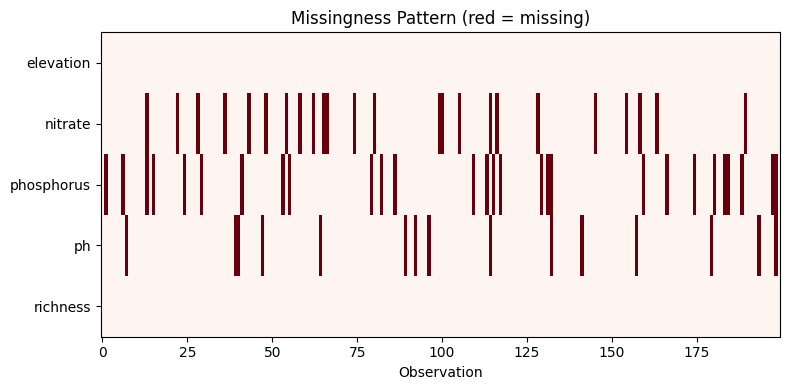

In [3]:
# Missingness rate per column
miss_rate = df.isnull().mean().sort_values(ascending=False)
print('Missingness rate:')
print(miss_rate.round(3))

# Is missingness in phosphorus related to elevation? (test for MAR)
df['phos_missing'] = df['phosphorus'].isnull()
elev_by_miss = df.groupby('phos_missing')['elevation'].agg(['mean','std']).round(2)
print('\nElevation by phosphorus missingness:')
print(elev_by_miss)
print('→ Higher mean elevation when phosphorus is missing → MAR, not MCAR')

# Missingness heatmap
numeric_cols = ['elevation', 'nitrate', 'phosphorus', 'ph', 'richness']
fig, ax = plt.subplots(figsize=(8, 4))
miss_matrix = df[numeric_cols].isnull().astype(int)
ax.imshow(miss_matrix.T, aspect='auto', cmap='Reds', interpolation='none')
ax.set_yticks(range(len(numeric_cols)))
ax.set_yticklabels(numeric_cols)
ax.set_xlabel('Observation')
ax.set_title('Missingness Pattern (red = missing)')
plt.tight_layout()
plt.show()

---
## Imputation Strategies

In [4]:
feature_cols = ['elevation', 'nitrate', 'phosphorus', 'ph']
X = df[feature_cols].values

# ── 1. Mean imputation (fast; distorts distribution) ─────────────────────────
mean_imp = SimpleImputer(strategy='mean')
X_mean = mean_imp.fit_transform(X)

# ── 2. Median imputation (robust to outliers) ─────────────────────────────────
median_imp = SimpleImputer(strategy='median')
X_median = median_imp.fit_transform(X)

# ── 3. Iterative (MICE-like) imputation ───────────────────────────────────────
# Models each feature as a function of all others; preserves correlations
iter_imp = IterativeImputer(random_state=42, max_iter=10)
X_iter = iter_imp.fit_transform(X)

# Compare imputed phosphorus distributions
missing_mask = df['phosphorus'].isnull()
phos_idx = feature_cols.index('phosphorus')

comparison = pd.DataFrame({
    'true':    complete.loc[missing_mask, 'phosphorus'].values,
    'mean':    X_mean[missing_mask, phos_idx],
    'median':  X_median[missing_mask, phos_idx],
    'iterative': X_iter[missing_mask, phos_idx]
})

print('RMSE vs true values (lower = better):')
for method in ['mean', 'median', 'iterative']:
    rmse = np.sqrt(((comparison['true'] - comparison[method])**2).mean())
    print(f'  {method:12s}: {rmse:.3f}')

RMSE vs true values (lower = better):
  mean        : 2.685
  median      : 2.811
  iterative   : 2.696


---
## Flagging Imputed Values

In [5]:
# Best practice: keep a record of which values were imputed
df_imputed = df[feature_cols].copy()

# Create missingness indicator columns before imputation
for col in feature_cols:
    df_imputed[f'{col}_imputed'] = df_imputed[col].isnull().astype(int)

# Apply iterative imputation
df_imputed[feature_cols] = X_iter

print('Imputation flags:')
flag_cols = [c for c in df_imputed.columns if '_imputed' in c]
print(df_imputed[flag_cols].sum())
print('\nSample rows with imputed phosphorus:')
print(df_imputed[df_imputed['phosphorus_imputed']==1][['phosphorus','phosphorus_imputed']].head(5))

Imputation flags:
elevation_imputed      0
nitrate_imputed       24
phosphorus_imputed    28
ph_imputed            15
dtype: int64

Sample rows with imputed phosphorus:
    phosphorus  phosphorus_imputed
1     2.144025                   1
6     2.010727                   1
13    1.984863                   1
15    2.231690                   1
24    2.003632                   1


---

## Common Pitfalls

**1. Using `dropna()` without investigating the mechanism**  
Complete-case analysis is unbiased only under MCAR. If missingness is related to any observed variable (MAR), dropping missing rows introduces systematic bias. Always investigate whether missingness is associated with other variables before deciding to drop.

**2. Imputing before splitting into train/test sets**  
Fitting an imputer on the full dataset before the train/test split leaks information from the test set into training. Always fit the imputer on training data only and apply it to both train and test. This applies to `IterativeImputer`, `SimpleImputer`, and any scaling or encoding step.

**3. Mean imputation for analysis (vs. prediction)**  
Mean imputation replaces all missing values with the same constant, collapsing the distribution and reducing variance. Correlations between the imputed variable and others are attenuated. For inference and effect estimation, use iterative or multiple imputation. Mean imputation is only defensible for prediction tasks where variance is less critical.

**4. Not creating missingness indicator columns before imputing**  
If data are MAR or MNAR, the fact that a value was missing is itself informative. Dropping this information after imputation loses a potentially predictive signal. Always create binary indicator columns (`col_was_missing`) before imputing, and include them as features in downstream models.

**5. Treating `0` as a valid value when it represents missing**  
In field data, `0` for species counts, flow measurements, or nutrient concentrations may be a true zero or a coded missing value depending on context. Treat these cases differently: a true zero (`nitrate = 0`) is meaningful; an instrument-below-detection entry coded as `0` should be `NaN` or a censored value. Clarify with data collection protocols before any analysis.

---
*python_methods_library · Samantha McGarrigle · [github.com/samantha-mcgarrigle](https://github.com/samantha-mcgarrigle)*